# Phase 15: Prediction Intervals

This notebook estimates prediction intervals for the Staten Island Railway OTP forecasting model.

Instead of only reporting a single predicted OTP value, this phase adds uncertainty ranges around the model predictions. Prediction intervals help communicate the expected range within which actual OTP may fall.

This phase uses residuals from the Phase 14 time-series cross-validation results to estimate forecast uncertainty.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("../outputs/reports", exist_ok=True)
os.makedirs("../outputs/predictions", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

In [2]:
cv_predictions_path = "../outputs/predictions/phase14_cv_predictions.csv"

df = pd.read_csv(cv_predictions_path)

df["month"] = pd.to_datetime(df["month"])

df.head()

,Fold,month,actual_otp,predicted_otp
0,1,2009-11-01,88.4,94.718920
1,1,2009-12-01,95.4,90.274430
2,1,2010-01-01,97.2,96.753420
3,1,2010-02-01,96.3,96.222880
4,1,2010-03-01,95.8,98.395195


In [3]:
df.columns
df.shape
df.head()
df.tail()

,Fold,month,actual_otp,predicted_otp
190,5,2025-09-01,98.6,97.039540
191,5,2025-10-01,97.4,95.619194
192,5,2025-11-01,92.2,93.413475
193,5,2025-12-01,98.0,95.598130
194,5,2026-01-01,96.4,96.923775


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Shape: (195, 4)

Columns:
Index(['Fold', 'month', 'actual_otp', 'predicted_otp'], dtype='object')


,Fold,month,actual_otp,predicted_otp
0,1,2009-11-01,88.4,94.718920
1,1,2009-12-01,95.4,90.274430
2,1,2010-01-01,97.2,96.753420
3,1,2010-02-01,96.3,96.222880
4,1,2010-03-01,95.8,98.395195


## Calculate Residuals

Residuals measure the difference between the actual OTP and the predicted OTP.

A positive residual means the model underpredicted OTP.  
A negative residual means the model overpredicted OTP.

These residuals are used to estimate the historical uncertainty of the model's forecasts.

In [5]:
# Calculate residuals and absolute errors
df["residual"] = df["actual_otp"] - df["predicted_otp"]
df["absolute_error"] = np.abs(df["residual"])

# Display results
df.head()

,Fold,month,actual_otp,predicted_otp,residual,absolute_error
0,1,2009-11-01,88.4,94.718920,-6.318920,6.318920
1,1,2009-12-01,95.4,90.274430,5.125570,5.125570
2,1,2010-01-01,97.2,96.753420,0.446580,0.446580
3,1,2010-02-01,96.3,96.222880,0.077120,0.077120
4,1,2010-03-01,95.8,98.395195,-2.595195,2.595195


In [6]:
df[["residual", "absolute_error"]].describe()

,residual,absolute_error
count,195.000000,195.000000
mean,0.377544,2.110707
std,2.980081,2.132161
min,-21.906080,0.024435
25%,-0.810608,0.821865
50%,0.818774,1.573690
75%,2.229983,2.808475
max,6.509660,21.906080


## Estimate Prediction Interval Bounds

Prediction intervals are estimated using the historical residual distribution from the time-series cross-validation results.

The 80% prediction interval uses the 10th and 90th percentiles of residuals.  
The 90% prediction interval uses the 5th and 95th percentiles of residuals.

These intervals are added around each model prediction to estimate a likely range for actual OTP.

In [7]:
# Calculate residual percentiles for prediction intervals
residual_p10 = np.percentile(df["residual"], 10)
residual_p90 = np.percentile(df["residual"], 90)

residual_p05 = np.percentile(df["residual"], 5)
residual_p95 = np.percentile(df["residual"], 95)

print("80% interval residual bounds:")
print("10th percentile:", residual_p10)
print("90th percentile:", residual_p90)

print("\n90% interval residual bounds:")
print("5th percentile:", residual_p05)
print("95th percentile:", residual_p95)

80% interval residual bounds:
10th percentile: -3.1264699999999945
90th percentile: 3.3576359999999985

90% interval residual bounds:
5th percentile: -4.479713699999999
95th percentile: 4.1960600000000055


In [8]:
# Create 80% prediction interval
df["lower_80"] = df["predicted_otp"] + residual_p10
df["upper_80"] = df["predicted_otp"] + residual_p90

# Create 90% prediction interval
df["lower_90"] = df["predicted_otp"] + residual_p05
df["upper_90"] = df["predicted_otp"] + residual_p95

# Clip intervals to realistic OTP bounds
df["lower_80"] = df["lower_80"].clip(lower=0, upper=100)
df["upper_80"] = df["upper_80"].clip(lower=0, upper=100)

df["lower_90"] = df["lower_90"].clip(lower=0, upper=100)
df["upper_90"] = df["upper_90"].clip(lower=0, upper=100)

df[[
    "month",
    "actual_otp",
    "predicted_otp",
    "lower_80",
    "upper_80",
    "lower_90",
    "upper_90"
]].head()

,month,actual_otp,predicted_otp,lower_80,upper_80,lower_90,upper_90
0,2009-11-01,88.4,94.718920,91.592450,98.076556,90.239206,98.91498
1,2009-12-01,95.4,90.274430,87.147960,93.632066,85.794716,94.47049
2,2010-01-01,97.2,96.753420,93.626950,100.000000,92.273706,100.00000
3,2010-02-01,96.3,96.222880,93.096410,99.580516,91.743166,100.00000
4,2010-03-01,95.8,98.395195,95.268725,100.000000,93.915481,100.00000


## Evaluate Interval Coverage

Coverage measures how often the actual OTP value falls inside the prediction interval.

For example, if the 80% prediction interval captures about 80% of actual values, the interval is well calibrated. If coverage is much lower, the interval may be too narrow. If coverage is much higher, the interval may be too wide.

In [9]:
# Check whether actual OTP falls inside each interval
df["inside_80"] = (
    (df["actual_otp"] >= df["lower_80"]) &
    (df["actual_otp"] <= df["upper_80"])
)

df["inside_90"] = (
    (df["actual_otp"] >= df["lower_90"]) &
    (df["actual_otp"] <= df["upper_90"])
)

# Calculate coverage
coverage_80 = df["inside_80"].mean() * 100
coverage_90 = df["inside_90"].mean() * 100

print(f"80% Prediction Interval Coverage: {coverage_80:.2f}%")
print(f"90% Prediction Interval Coverage: {coverage_90:.2f}%")

80% Prediction Interval Coverage: 79.49%
90% Prediction Interval Coverage: 89.74%


In [10]:
coverage_summary = pd.DataFrame({
    "Interval": ["80% Prediction Interval", "90% Prediction Interval"],
    "Lower_Residual_Bound": [residual_p10, residual_p05],
    "Upper_Residual_Bound": [residual_p90, residual_p95],
    "Coverage_Percentage": [coverage_80, coverage_90],
    "Average_Interval_Width": [
        (df["upper_80"] - df["lower_80"]).mean(),
        (df["upper_90"] - df["lower_90"]).mean()
    ]
})

coverage_summary = coverage_summary.round(4)

coverage_summary

,Interval,Lower_Residual_Bound,Upper_Residual_Bound,Coverage_Percentage,Average_Interval_Width
0,80% Prediction Interval,-3.1265,3.3576,79.4872,6.2958
1,90% Prediction Interval,-4.4797,4.1961,89.7436,8.1776


In [11]:
# Save prediction intervals
df.to_csv(
    "../outputs/predictions/phase15_prediction_intervals.csv",
    index=False
)

# Save coverage summary
coverage_summary.to_csv(
    "../outputs/reports/phase15_prediction_interval_summary.csv",
    index=False
)

In [12]:
print("Saved prediction interval outputs successfully.")
print("Prediction interval file rows:", df.shape[0])
print("Coverage summary rows:", coverage_summary.shape[0])

Saved prediction interval outputs successfully.
Prediction interval file rows: 195
Coverage summary rows: 2


## Visualize Interval Coverage

The coverage chart compares the intended prediction interval coverage with the actual observed coverage. A well-calibrated interval should have actual coverage close to the intended coverage level.

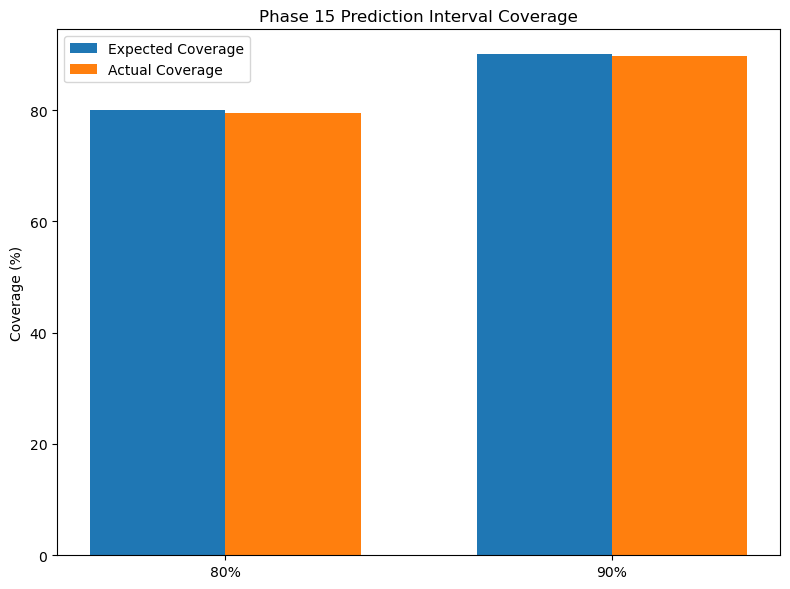

In [13]:
coverage_plot_df = pd.DataFrame({
    "Interval": ["80%", "90%"],
    "Expected_Coverage": [80, 90],
    "Actual_Coverage": [coverage_80, coverage_90]
})

plt.figure(figsize=(8, 6))

x = np.arange(len(coverage_plot_df["Interval"]))
width = 0.35

plt.bar(
    x - width / 2,
    coverage_plot_df["Expected_Coverage"],
    width,
    label="Expected Coverage"
)

plt.bar(
    x + width / 2,
    coverage_plot_df["Actual_Coverage"],
    width,
    label="Actual Coverage"
)

plt.xticks(x, coverage_plot_df["Interval"])
plt.ylabel("Coverage (%)")
plt.title("Phase 15 Prediction Interval Coverage")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../outputs/figures/phase15_interval_coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The coverage chart shows that the residual-based prediction intervals are well calibrated. The 80% interval captured 79.49% of actual OTP values, while the 90% interval captured 89.74%. Because the observed coverage is very close to the expected coverage, these intervals provide a reasonable estimate of forecast uncertainty.

## Visualize Prediction Intervals

The prediction interval chart shows actual OTP, predicted OTP, and the estimated 80% and 90% prediction intervals. For readability, the chart below focuses on the most recent cross-validation fold.

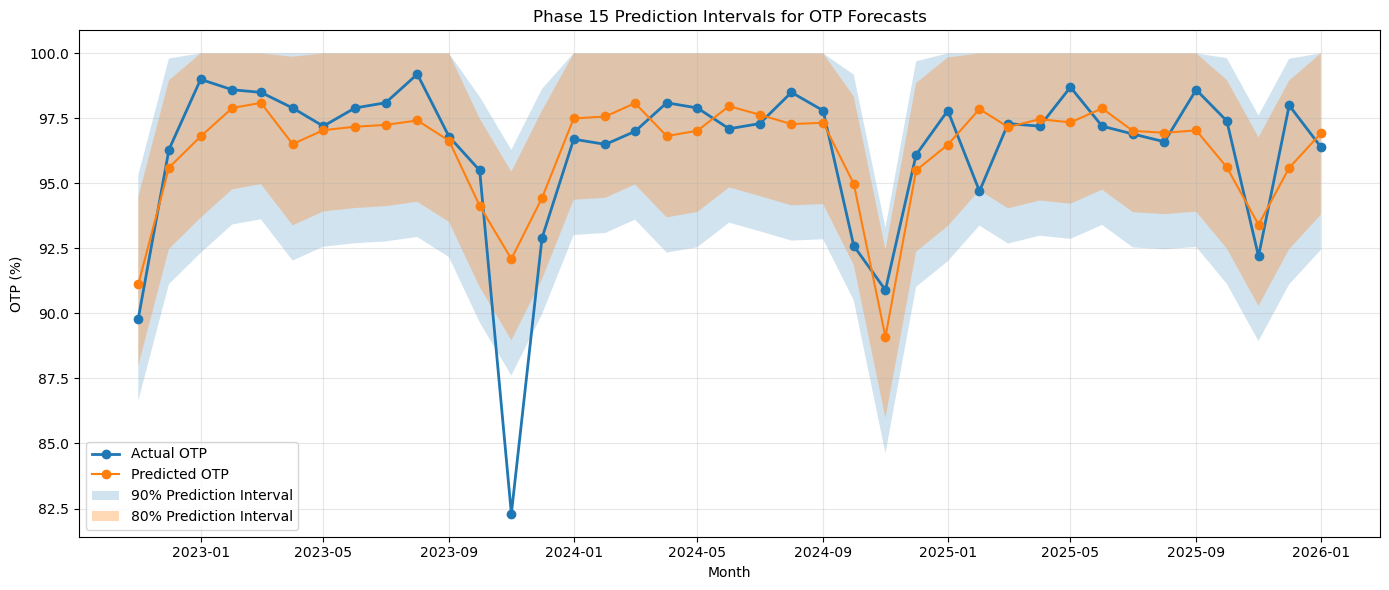

In [14]:
# Use the most recent fold for a clean visualization
latest_fold = df["Fold"].max()

plot_df = df[df["Fold"] == latest_fold].copy()
plot_df = plot_df.sort_values("month")

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df["month"],
    plot_df["actual_otp"],
    marker="o",
    linewidth=2,
    label="Actual OTP"
)

plt.plot(
    plot_df["month"],
    plot_df["predicted_otp"],
    marker="o",
    label="Predicted OTP"
)

plt.fill_between(
    plot_df["month"],
    plot_df["lower_90"],
    plot_df["upper_90"],
    alpha=0.2,
    label="90% Prediction Interval"
)

plt.fill_between(
    plot_df["month"],
    plot_df["lower_80"],
    plot_df["upper_80"],
    alpha=0.3,
    label="80% Prediction Interval"
)

plt.title("Phase 15 Prediction Intervals for OTP Forecasts")
plt.xlabel("Month")
plt.ylabel("OTP (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/phase15_prediction_intervals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The prediction interval chart shows the model's point forecasts along with 80% and 90% uncertainty ranges. Most actual OTP values fall within the estimated intervals, indicating that the residual-based approach provides useful uncertainty estimates.

The wider 90% interval captures more actual values than the 80% interval, as expected. Months with sharp OTP drops are more difficult to capture, suggesting that unexpected operational disruptions may require additional features such as weather, incident-level delays, track work, or ferry connection effects.

In [15]:
findings_text = f"""
Phase 15 estimated prediction intervals for the Staten Island Railway OTP forecasting model using residuals from Phase 14 time-series cross-validation.

The residual-based 80% prediction interval used the 10th and 90th percentiles of historical residuals. The residual-based 90% prediction interval used the 5th and 95th percentiles of historical residuals.

The 80% prediction interval achieved an observed coverage of {coverage_80:.2f}%, while the 90% prediction interval achieved an observed coverage of {coverage_90:.2f}%. These values are close to the expected coverage levels, suggesting that the prediction intervals are reasonably well calibrated.

The average width of the 80% interval was {coverage_summary.loc[0, "Average_Interval_Width"]:.4f} OTP percentage points, while the average width of the 90% interval was {coverage_summary.loc[1, "Average_Interval_Width"]:.4f} OTP percentage points.

Overall, this phase improves the forecasting framework by moving beyond point predictions and adding uncertainty ranges around OTP forecasts. This is useful for operational decision-making because it communicates not only the expected OTP value, but also the range within which actual OTP may reasonably fall.
"""

print(findings_text)


Phase 15 estimated prediction intervals for the Staten Island Railway OTP forecasting model using residuals from Phase 14 time-series cross-validation.

The residual-based 80% prediction interval used the 10th and 90th percentiles of historical residuals. The residual-based 90% prediction interval used the 5th and 95th percentiles of historical residuals.

The 80% prediction interval achieved an observed coverage of 79.49%, while the 90% prediction interval achieved an observed coverage of 89.74%. These values are close to the expected coverage levels, suggesting that the prediction intervals are reasonably well calibrated.

The average width of the 80% interval was 6.2958 OTP percentage points, while the average width of the 90% interval was 8.1776 OTP percentage points.

Overall, this phase improves the forecasting framework by moving beyond point predictions and adding uncertainty ranges around OTP forecasts. This is useful for operational decision-making because it communicates no

In [16]:
with open("../outputs/reports/phase15_findings.txt", "w") as f:
    f.write(findings_text)

# Phase 15 Findings

Phase 15 estimated prediction intervals for the Staten Island Railway OTP forecasting model using residuals from Phase 14 time-series cross-validation.

The residual-based 80% prediction interval used the 10th and 90th percentiles of historical residuals, while the 90% prediction interval used the 5th and 95th percentiles. This approach estimates uncertainty based on how much the model was historically overpredicting or underpredicting OTP during cross-validation.

The 80% prediction interval achieved an observed coverage of **79.49%**, while the 90% prediction interval achieved an observed coverage of **89.74%**. These values are very close to the expected 80% and 90% coverage levels, suggesting that the intervals are reasonably well calibrated.

The average width of the 80% interval was **6.2958 OTP percentage points**, while the average width of the 90% interval was **8.1776 OTP percentage points**. The wider 90% interval captures more uncertainty, as expected.

Overall, Phase 15 improves the forecasting framework by moving beyond point predictions and adding uncertainty ranges around OTP forecasts. This is useful for operational decision-making because it communicates not only the expected OTP value, but also the range within which actual OTP may reasonably fall.